# Polarimetry-initialized anisotropic remodeling

This notebook closes the first data-to-model loop:

\[
\alpha(X,Y),R(X,Y)
\rightarrow \mathbf a_0(X,Y),\beta(X,Y)
\rightarrow \text{mechanical loading}
\rightarrow \mathbf a_0(X,Y,t),\beta(X,Y,t).
\]

The deformation is prescribed and compatible. Each accepted image pixel is treated as an independent material point. This is a transparent baseline for later finite-element coupling, not yet an equilibrium solution.

Because the input maps are synthetic and their ground-truth structural fields are known, the notebook also performs an **oracle comparison**. The reconstructed initialization and the exact synthetic initialization are propagated through the same remodeling model, allowing reconstruction error to be tracked into the predicted mechanical and structural response.

## 1. Environment and imports

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate repository root.")

ROOT = find_repository_root(Path.cwd().resolve())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from anisotropic_remodeling import (  # noqa: E402
    MaterialParameters,
    angle_to_vector,
    PolarimetryRemodelingConfig,
    RemodelingParameters,
    RetardanceCalibration,
    local_nematic_coherence,
    polarimetry_to_structure,
    run_polarimetry_initialized_remodeling,
)

np.set_printoptions(precision=6, suppress=True)
print(f"Repository root: {ROOT}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling


## 2. Load synthetic polarimetric measurements

In [2]:
raw_path = ROOT / "data" / "synthetic" / "polarimetry_maps.npz"
raw = np.load(raw_path)

x = raw["x"]
y = raw["y"]
observed_azimuth = raw["azimuth_rad"]
observed_retardance = raw["retardance"]
tissue_mask = raw["tissue_mask"]

print(f"Grid shape: {x.shape}")
print(f"Tissue pixels: {int(np.sum(tissue_mask))}")
print(f"Azimuth finite in tissue: {int(np.sum(np.isfinite(observed_azimuth) & tissue_mask))}")

Grid shape: (81, 121)
Tissue pixels: 6951
Azimuth finite in tissue: 6951


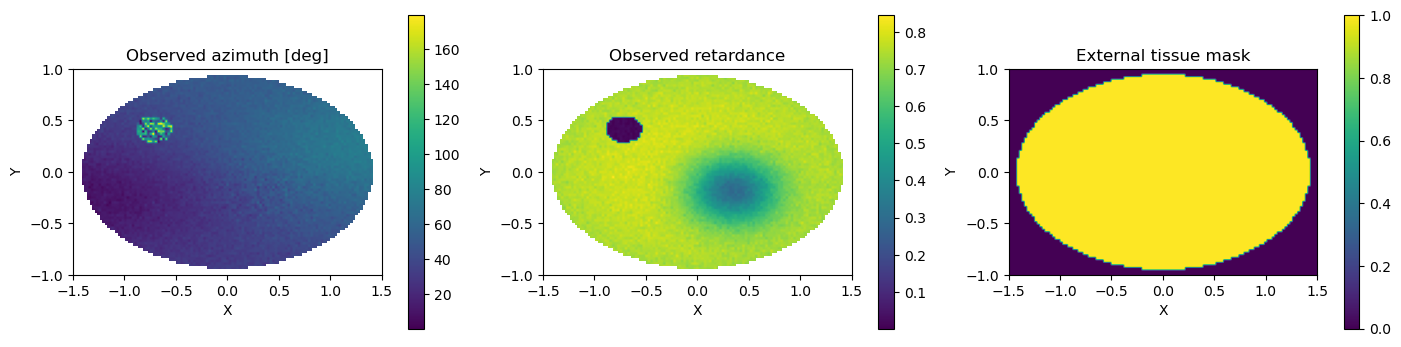

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
extent=(x.min(), x.max(), y.min(), y.max())
images = [
    axes[0].imshow(np.rad2deg(observed_azimuth), origin="lower", extent=extent, aspect="equal"),
    axes[1].imshow(observed_retardance, origin="lower", extent=extent, aspect="equal"),
    axes[2].imshow(tissue_mask, origin="lower", extent=extent, aspect="equal"),
]
axes[0].set_title("Observed azimuth [deg]")
axes[1].set_title("Observed retardance")
axes[2].set_title("External tissue mask")
for ax, im in zip(axes, images):
    ax.set(xlabel="X", ylabel="Y")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 3. Reconstruct model-ready structural fields

The retardance-derived order is an explicit calibrated proxy, not a universal absolute measurement of tissue order. The final initial condition combines this proxy with local nematic coherence and an explicit validity mask.

In [4]:
calibration = RetardanceCalibration(
    lower_retardance=0.04,
    upper_retardance=0.90,
    beta_min=0.05,
    beta_max=0.95,
    exponent=1.30,
)

structure = polarimetry_to_structure(
    observed_azimuth,
    observed_retardance,
    calibration,
    minimum_valid_retardance=0.08,
    external_valid_mask=tissue_mask,
    coherence_window=9,
)

valid = structure.valid_mask
print(f"Valid model pixels: {int(np.sum(valid))}")
print(f"Valid fraction of tissue: {np.sum(valid) / np.sum(tissue_mask):.4f}")
print(f"Initial mean beta: {np.nanmean(structure.structural_order):.6f}")

Valid model pixels: 6836
Valid fraction of tissue: 0.9835
Initial mean beta: 0.703541


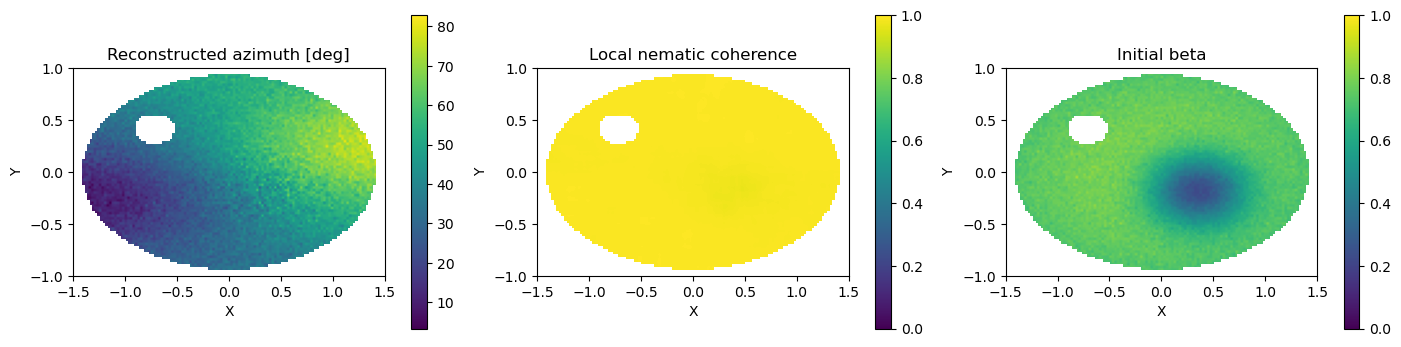

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
fields = [
    np.rad2deg(structure.azimuth_rad),
    structure.local_coherence,
    structure.structural_order,
]
titles = ["Reconstructed azimuth [deg]", "Local nematic coherence", "Initial beta"]
for ax, field, title in zip(axes, fields, titles):
    im=ax.imshow(field, origin="lower", extent=extent, aspect="equal", vmin=0 if title!="Reconstructed azimuth [deg]" else None, vmax=1 if title!="Reconstructed azimuth [deg]" else None)
    ax.set(title=title, xlabel="X", ylabel="Y")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 4. Configure material, kinetics, and prescribed loading

In [6]:
config = PolarimetryRemodelingConfig(
    total_time=12.0,
    dt=0.1,
    ramp_duration=4.0,
    maximum_stretch=1.18,
    maximum_shear=0.35,
    half_height=float(np.max(np.abs(y))),
)
material = MaterialParameters(mu=10.0, kappa=1000.0, k1=2.0, k2=5.0)
remodeling = RemodelingParameters(
    orientation_rate=0.25,
    order_rate=0.15,
    beta_min=0.10,
    beta_max=1.00,
    half_saturation=0.20,
    hill_exponent=2.0,
)
print(config)
print(material)
print(remodeling)

PolarimetryRemodelingConfig(total_time=12.0, dt=0.1, ramp_duration=4.0, maximum_stretch=1.18, maximum_shear=0.35, half_height=1.0)
MaterialParameters(mu=10.0, kappa=1000.0, k1=2.0, k2=5.0)
RemodelingParameters(orientation_rate=0.25, order_rate=0.15, beta_min=0.1, beta_max=1.0, half_saturation=0.2, hill_exponent=2.0)


## 5. Run polarimetry-initialized remodeling

In [7]:
result = run_polarimetry_initialized_remodeling(
    x,
    y,
    structure.fiber_direction,
    structure.structural_order,
    structure.valid_mask,
    config,
    material,
    remodeling,
    snapshot_times=(0.0, config.ramp_duration, config.total_time),
)

print(f"Time points: {result.time.size}")
print(f"Snapshots: {result.snapshot_time}")
print(f"Initial mean beta: {result.mean_structural_order[0]:.6f}")
print(f"Final mean beta:   {result.mean_structural_order[-1]:.6f}")
print(f"Initial alignment: {result.mean_target_alignment[0]:.6f}")
print(f"Final alignment:   {result.mean_target_alignment[-1]:.6f}")
print(f"Final mean sigma_xx: {result.mean_cauchy_stress_xx[-1]:.6f}")

Time points: 121
Snapshots: [ 0.  4. 12.]
Initial mean beta: 0.703541
Final mean beta:   0.765918
Initial alignment: 0.457692
Final alignment:   0.988519
Final mean sigma_xx: 14.024246


### 5.1 Oracle propagation of reconstruction error

The synthetic dataset contains the exact azimuth and retardance-derived order fields used to generate the noisy observations. We reconstruct the corresponding exact structural state and evolve it with exactly the same material, loading, kinetic parameters, time step, and validity mask.

This comparison does **not** validate the biological evolution law. It isolates a narrower question:

> How much error in the reconstructed initial structure remains in the predicted remodeled structure and mechanical response?

In [8]:
true_azimuth = raw["true_azimuth_rad"]
true_retardance_order = raw["true_retardance_order"]

true_coherence = local_nematic_coherence(
    true_azimuth,
    window_size=9,
    weights=np.where(tissue_mask, true_retardance_order, 0.0),
    valid_mask=tissue_mask,
)
true_structural_order = true_retardance_order * true_coherence
true_fiber_direction = angle_to_vector(true_azimuth)

# Use the same accepted pixels as the reconstructed simulation so that all
# differences arise from initialization rather than from domain mismatch.
true_fiber_direction = np.where(valid[..., None], true_fiber_direction, np.nan)
true_structural_order = np.where(valid, true_structural_order, np.nan)

oracle_result = run_polarimetry_initialized_remodeling(
    x,
    y,
    true_fiber_direction,
    true_structural_order,
    valid,
    config,
    material,
    remodeling,
    snapshot_times=(0.0, config.ramp_duration, config.total_time),
)


def nematic_direction_error_deg(first: np.ndarray, second: np.ndarray) -> np.ndarray:
    dot_product = np.einsum("...i,...i->...", first, second)
    return np.rad2deg(np.arccos(np.clip(np.abs(dot_product), 0.0, 1.0)))


initial_angle_error = nematic_direction_error_deg(
    result.fiber_direction[0, valid],
    oracle_result.fiber_direction[0, valid],
)
final_angle_error = nematic_direction_error_deg(
    result.fiber_direction[-1, valid],
    oracle_result.fiber_direction[-1, valid],
)
initial_beta_error = result.structural_order[0, valid] - oracle_result.structural_order[0, valid]
final_beta_error = result.structural_order[-1, valid] - oracle_result.structural_order[-1, valid]

oracle_metrics = {
    "initial_mean_angle_error_deg": float(np.mean(initial_angle_error)),
    "final_mean_angle_error_deg": float(np.mean(final_angle_error)),
    "initial_beta_rmse": float(np.sqrt(np.mean(initial_beta_error**2))),
    "final_beta_rmse": float(np.sqrt(np.mean(final_beta_error**2))),
    "final_mean_sigma_xx_difference": float(
        result.mean_cauchy_stress_xx[-1] - oracle_result.mean_cauchy_stress_xx[-1]
    ),
    "final_mean_beta_difference": float(
        result.mean_structural_order[-1] - oracle_result.mean_structural_order[-1]
    ),
}

for name, value in oracle_metrics.items():
    print(f"{name}: {value:.8f}")

initial_mean_angle_error_deg: 2.38269817
final_mean_angle_error_deg: 0.31172949
initial_beta_rmse: 0.01914853
final_beta_rmse: 0.00316523
final_mean_sigma_xx_difference: -0.00832424
final_mean_beta_difference: -0.00059286


## 6. Spatial evolution of structural order

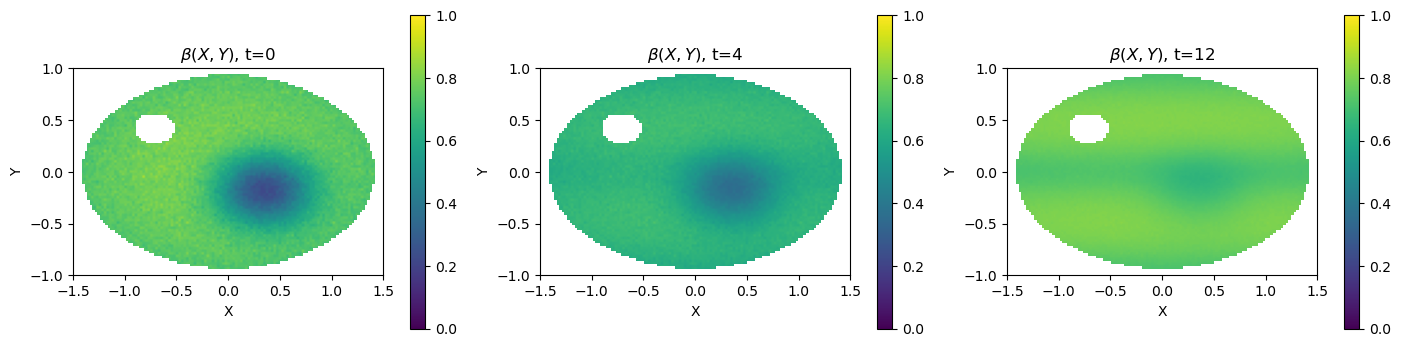

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for i, time_value in enumerate(result.snapshot_time):
    im=axes[i].imshow(result.structural_order[i], origin="lower", extent=extent, aspect="equal", vmin=0, vmax=1)
    axes[i].set(title=fr"$\beta(X,Y)$, t={time_value:g}", xlabel="X", ylabel="Y")
    fig.colorbar(im, ax=axes[i], shrink=0.8)
plt.show()

### 6.1 Reconstructed prediction versus oracle prediction

results\figures\polarimetry_initialized_remodeling_summary.png


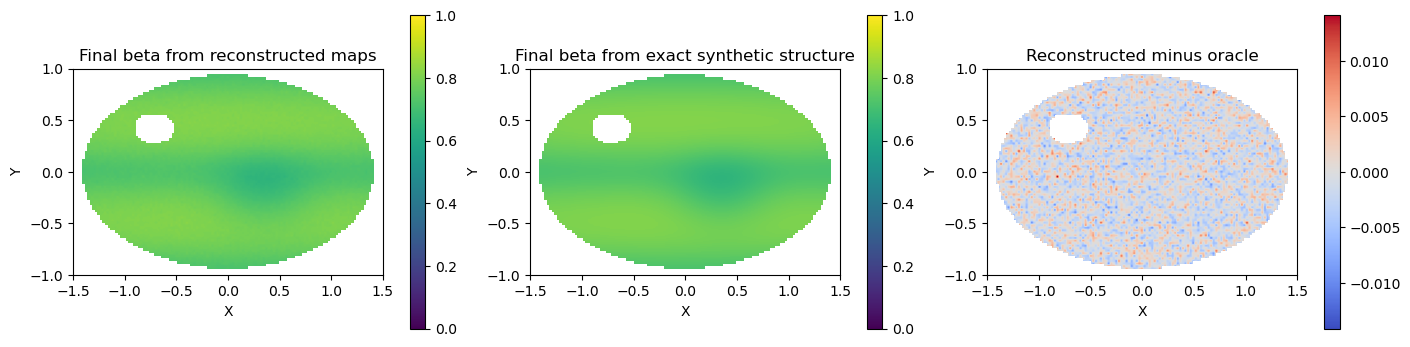

In [10]:
final_beta_difference = result.structural_order[-1] - oracle_result.structural_order[-1]
finite_difference = final_beta_difference[valid]
comparison_limit = float(np.max(np.abs(finite_difference)))
comparison_limit = max(comparison_limit, 1.0e-12)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
fields = [
    result.structural_order[-1],
    oracle_result.structural_order[-1],
    final_beta_difference,
]
titles = [
    "Final beta from reconstructed maps",
    "Final beta from exact synthetic structure",
    "Reconstructed minus oracle",
]
settings = [
    {"vmin": 0.0, "vmax": 1.0},
    {"vmin": 0.0, "vmax": 1.0},
    {"vmin": -comparison_limit, "vmax": comparison_limit, "cmap": "coolwarm"},
]
for axis, field, title, kwargs in zip(axes, fields, titles, settings):
    image = axis.imshow(
        field,
        origin="lower",
        extent=extent,
        aspect="equal",
        **kwargs,
    )
    axis.set(title=title, xlabel="X", ylabel="Y")
    fig.colorbar(image, ax=axis, shrink=0.8)

summary_figure_path = ROOT / "results" / "figures" / "polarimetry_initialized_remodeling_summary.png"
summary_figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(summary_figure_path, dpi=180, bbox_inches="tight")
print(summary_figure_path.relative_to(ROOT))
plt.show()

## 7. Spatial evolution of fiber orientation

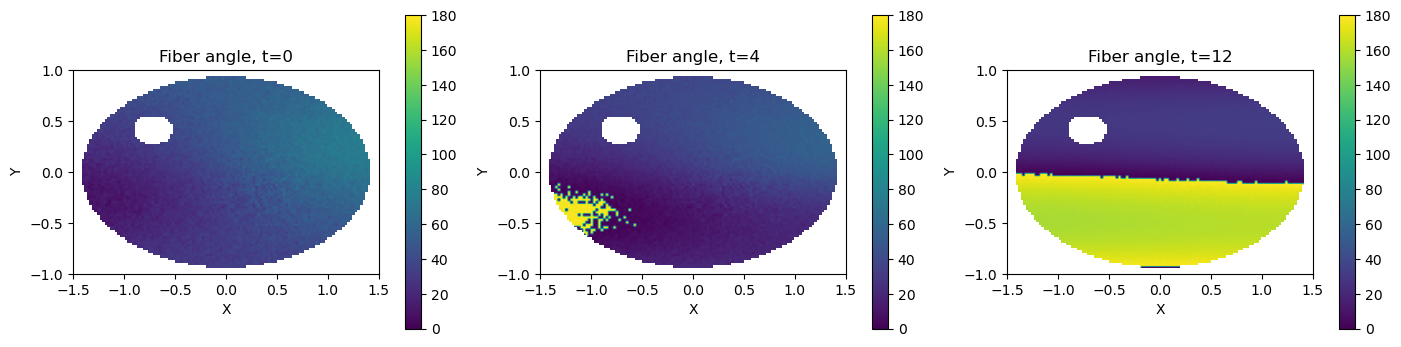

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for i, time_value in enumerate(result.snapshot_time):
    angle=result.fiber_angle_deg[i]
    im=axes[i].imshow(angle, origin="lower", extent=extent, aspect="equal", vmin=0, vmax=180)
    axes[i].set(title=f"Fiber angle, t={time_value:g}", xlabel="X", ylabel="Y")
    fig.colorbar(im, ax=axes[i], shrink=0.8)
plt.show()

## 8. Mechanical fields at final time

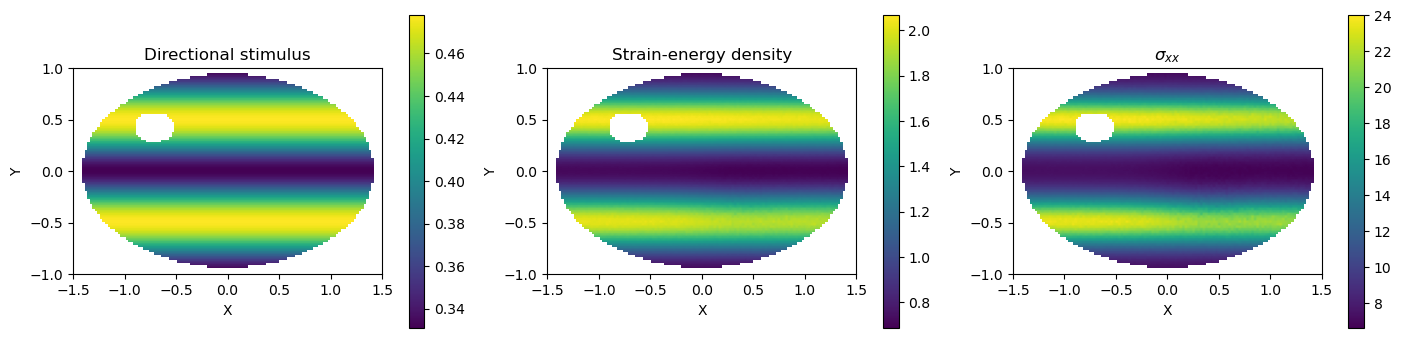

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
final_fields=[result.stimulus[-1], result.strain_energy[-1], result.cauchy_stress[-1,...,0,0]]
titles=["Directional stimulus", "Strain-energy density", r"$\sigma_{xx}$"]
for ax, field, title in zip(axes, final_fields, titles):
    im=ax.imshow(field, origin="lower", extent=extent, aspect="equal")
    ax.set(title=title, xlabel="X", ylabel="Y")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 9. Global histories

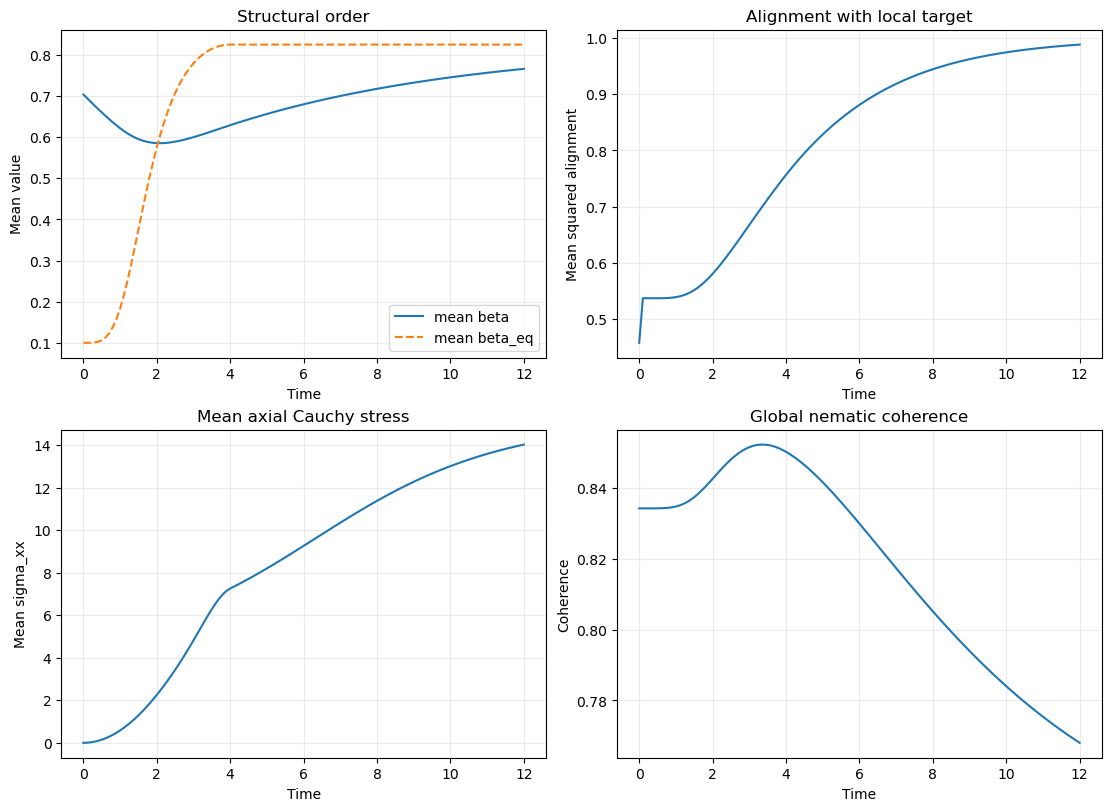

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
axes[0,0].plot(result.time, result.mean_structural_order, label="mean beta")
axes[0,0].plot(result.time, result.mean_equilibrium_order, "--", label="mean beta_eq")
axes[0,0].set(title="Structural order", xlabel="Time", ylabel="Mean value")
axes[0,0].legend()
axes[0,1].plot(result.time, result.mean_target_alignment)
axes[0,1].set(title="Alignment with local target", xlabel="Time", ylabel="Mean squared alignment")
axes[1,0].plot(result.time, result.mean_cauchy_stress_xx)
axes[1,0].set(title="Mean axial Cauchy stress", xlabel="Time", ylabel="Mean sigma_xx")
axes[1,1].plot(result.time, result.orientation_coherence)
axes[1,1].set(title="Global nematic coherence", xlabel="Time", ylabel="Coherence")
for ax in axes.flat:
    ax.grid(True, alpha=0.25)
plt.show()

### 9.1 Global reconstructed–oracle differences

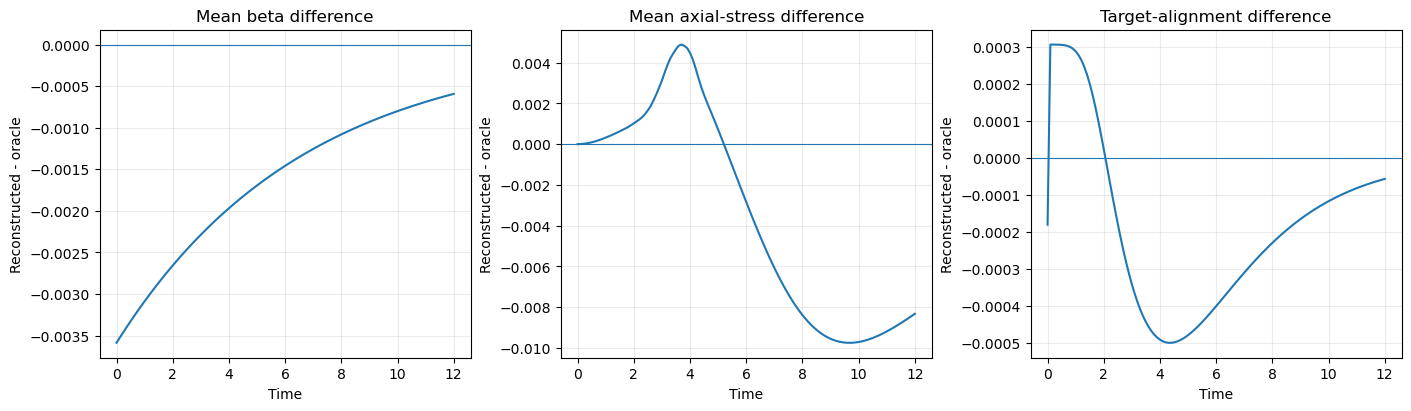

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].plot(
    result.time,
    result.mean_structural_order - oracle_result.mean_structural_order,
)
axes[0].set(title="Mean beta difference", xlabel="Time", ylabel="Reconstructed - oracle")

axes[1].plot(
    result.time,
    result.mean_cauchy_stress_xx - oracle_result.mean_cauchy_stress_xx,
)
axes[1].set(title="Mean axial-stress difference", xlabel="Time", ylabel="Reconstructed - oracle")

axes[2].plot(
    result.time,
    result.mean_target_alignment - oracle_result.mean_target_alignment,
)
axes[2].set(title="Target-alignment difference", xlabel="Time", ylabel="Reconstructed - oracle")

for axis in axes:
    axis.axhline(0.0, linewidth=0.8)
    axis.grid(True, alpha=0.25)
plt.show()

## 10. Physical and numerical checks

In [15]:
valid_snapshots = np.broadcast_to(valid, result.structural_order.shape)
beta_values = result.structural_order[valid_snapshots]
fiber_values = result.fiber_direction[np.broadcast_to(valid[...,None], result.fiber_direction.shape)]
fiber_values = fiber_values.reshape(-1,2)
stress_valid = result.cauchy_stress[:, valid]
F_valid = result.deformation_gradient[:, valid]
checks = {
    "invalid beta remains NaN": bool(np.all(np.isnan(result.structural_order[:, ~valid]))),
    "valid beta finite": bool(np.all(np.isfinite(beta_values))),
    "beta bounded": bool(np.all((beta_values >= 0) & (beta_values <= 1))),
    "unit fibers": bool(np.allclose(np.linalg.norm(fiber_values, axis=-1), 1.0, atol=1e-12)),
    "positive Jacobian": bool(np.all(np.linalg.det(F_valid) > 0)),
    "area preservation": bool(np.allclose(np.linalg.det(F_valid), 1.0, atol=1e-12)),
    "symmetric Cauchy stress": bool(np.allclose(stress_valid, np.swapaxes(stress_valid,-1,-2), atol=1e-12)),
    "alignment increases": bool(result.mean_target_alignment[-1] > result.mean_target_alignment[0]),
    "oracle valid fields finite": bool(np.all(np.isfinite(oracle_result.structural_order[:, valid]))),
    "identical prescribed kinematics": bool(np.allclose(result.deformation_gradient, oracle_result.deformation_gradient, equal_nan=True)),
}
for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")
assert all(checks.values())

PASS — invalid beta remains NaN
PASS — valid beta finite
PASS — beta bounded
PASS — unit fibers
PASS — positive Jacobian
PASS — area preservation
PASS — symmetric Cauchy stress
PASS — alignment increases
PASS — oracle valid fields finite
PASS — identical prescribed kinematics


## 11. Export reproducible results

In [16]:
out_dir = ROOT / "results" / "data"
out_dir.mkdir(parents=True, exist_ok=True)
npz_path = out_dir / "polarimetry_initialized_remodeling_snapshots.npz"
np.savez_compressed(
    npz_path,
    x=result.x,
    y=result.y,
    valid_mask=result.valid_mask,
    snapshot_time=result.snapshot_time,
    deformation_gradient=result.deformation_gradient,
    reconstructed_fiber_direction=result.fiber_direction,
    reconstructed_fiber_angle_deg=result.fiber_angle_deg,
    reconstructed_structural_order=result.structural_order,
    reconstructed_equilibrium_order=result.equilibrium_order,
    reconstructed_stimulus=result.stimulus,
    reconstructed_strain_energy=result.strain_energy,
    reconstructed_cauchy_stress=result.cauchy_stress,
    oracle_fiber_direction=oracle_result.fiber_direction,
    oracle_fiber_angle_deg=oracle_result.fiber_angle_deg,
    oracle_structural_order=oracle_result.structural_order,
    oracle_strain_energy=oracle_result.strain_energy,
    oracle_cauchy_stress=oracle_result.cauchy_stress,
)

csv_path = out_dir / "polarimetry_initialized_remodeling_history.csv"
history = np.column_stack(
    (
        result.time,
        result.mean_structural_order,
        oracle_result.mean_structural_order,
        result.mean_equilibrium_order,
        result.mean_stimulus,
        result.mean_strain_energy,
        oracle_result.mean_strain_energy,
        result.mean_cauchy_stress_xx,
        oracle_result.mean_cauchy_stress_xx,
        result.orientation_coherence,
        oracle_result.orientation_coherence,
        result.mean_orientation_angle_deg,
        oracle_result.mean_orientation_angle_deg,
        result.mean_target_alignment,
        oracle_result.mean_target_alignment,
    )
)
header = ",".join(
    (
        "time",
        "reconstructed_mean_beta",
        "oracle_mean_beta",
        "mean_beta_equilibrium",
        "mean_stimulus",
        "reconstructed_mean_strain_energy",
        "oracle_mean_strain_energy",
        "reconstructed_mean_sigma_xx",
        "oracle_mean_sigma_xx",
        "reconstructed_orientation_coherence",
        "oracle_orientation_coherence",
        "reconstructed_mean_orientation_angle_deg",
        "oracle_mean_orientation_angle_deg",
        "reconstructed_mean_target_alignment",
        "oracle_mean_target_alignment",
    )
)
np.savetxt(csv_path, history, delimiter=",", header=header, comments="")

metrics_path = out_dir / "polarimetry_initialized_oracle_metrics.csv"
metric_names = np.array(list(oracle_metrics.keys()), dtype=str)
metric_values = np.array(list(oracle_metrics.values()), dtype=float)
with metrics_path.open("w", encoding="utf-8") as stream:
    stream.write("metric,value\n")
    for name, value in zip(metric_names, metric_values):
        stream.write(f"{name},{value:.12g}\n")

print(npz_path.relative_to(ROOT))
print(csv_path.relative_to(ROOT))
print(metrics_path.relative_to(ROOT))

results\data\polarimetry_initialized_remodeling_snapshots.npz
results\data\polarimetry_initialized_remodeling_history.csv
results\data\polarimetry_initialized_oracle_metrics.csv


## 12. Interpretation and limitations

The reconstructed synthetic image-derived fields are valid initial conditions of the constitutive-remodeling model. The simulation preserves the synthetic validity mask, evolves local fiber direction and structural order, and returns spatial mechanical fields and global summaries.

The oracle comparison separates **measurement/reconstruction error** from the behavior of the remodeling equations. Both simulations receive identical kinematics and parameters; only their initial structural fields differ. Therefore, discrepancies in their later predictions quantify how the synthetic reconstruction error propagates through this specific computational pipeline.

This benchmark isolates structural reconstruction and remodeling. The present model still prescribes \(\mathbf F(X,Y,t)\), neighboring pixels do not communicate mechanically, and image holes do not define physical boundaries. The next major methodological step is an equilibrium-based finite-element formulation in which reconstructed structural fields become material coefficients over a tissue-domain mesh.